<center>
    <h1>HỌC PHẦN:<br> KHAI PHÁ DỮ LIỆU - DATA MINING (7080508) </h1>
    <h2>Bài tập tổng hợp - Chương 1, 2 </h2>
</center>

---
    
**THÔNG TIN SINH VIÊN:**
    
1. Họ và tên: Trần Việt Anh
2. Mã Sinh viên: 2221050164
3. Nhóm môn học: 100 (em chuyển sang học cùng nhóm 1)

**MÔ TẢ BÀI TOÁN:**
Một hãng hàng không thực hiện khảo sát khách hàng đánh giá về các dịch vụ của hãng bay; với 2 nhóm dữ liệu


**A. Các thông tin chung của hành khách và chuyến bay: Dữ liệu được lưu trữ trong file CSV**
1. Code: Mã hành khách
2. Gender: Giới tính của hành khách (Male|Female)
3. Customer Type: Loại hành khách. 
    * Khách hàng thân thiết (Loyal Customer): Khách hàng đã đi nhiều lần (>=2) với hãng
    * Khách hàng không thân thiết (disloyal Customer): Khách hàng không thân thiết (sử dụng dịch vụ bay lần đầu của hãng)
4. Age: Tuổi của hành khách
5. State: Địa chỉ của hành khách
5. Type of Travel: Mục đích đi máy bay
    * Đi với mục đích công việc (Business travel)
    * Đi với mục đích cá nhân (Personal Travel)
6. Class: Loại vé (Business | Eco Plus | Eco)
7. Flight Distance: Khoảng cách di chuyển của chuyến bay (Mile)
8. Departure Delay in Minutes: Thời gian trễ của chuyến bay tại ga xuất phát (Phút)
9. Arrival Delay in Minutes: Thời gian trễ của chuyến bay tại ga đến (phút)


**B. Chiến dịch khảo sát được thực hiện trong suốt 12 tháng trong năm 2020, dữ liệu được lưu trong file Excel với từng sheet tương ứng là dữ liệu khảo sát trong từng tháng:** Thang chấm từ 0 (thấp nhất)  --> 5 (cao nhất)

1. Code: Mã khách hàng
2. Inflight wifi service: Dịch vụ wifi trên chuyến bay
3. Departure/Arrival time convenient: Mức độ thuận tiện trong thời gian ở Ga khởi hành| Ga đến
4. Ease of Online booking: Mức độ dễ đàng khi đặt vé Online
5. Food and drink: Đồ ăn và đồ uống phục vụ trên chuyến bay
6. Seat comfort: Sự thoải mái của chỗ ngồi
7. Inflight entertainment: Dịch vụ giải trí trên chuyến bay
8. Baggage handling: Vấn đề liên quan đến hành lý xách tay
9. Checkin service: Dịch vụ checkin
10. Inflight service: Dịch vụ trên chuyến bay
11. Cleanliness: Vệ sinh trên chuyến bay
12. satisfaction: Tổng quan chung về mức độ hài lòng.
    * KHÔNG HÀI LÒNG với chuyến bay (neutral or dissatisfied)
    * HÀI LÒNG với chuyến bay (satisfied)

## Yêu cầu 1. Tích hợp dữ liệu
---
Dữ liệu liên quan đến dự án đang được lưu trữ ở 2 file với 2 định dạng khác nhau; Hãy tìm hiểu và tích hợp 2 file dữ liệu thành 1 file dữ liệu duy nhất (Dataset) để phục vụ cho việc phân tích. 

In [1]:
#Gọi các thư viện sử dụng:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#-------------------------------------
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Sinh viên viết mã xử lý vào đây!
# đọc dữ liệu hành khách
df_passenger = pd.read_csv("Data_Passenger_Airlines.csv")

df_passenger.head()

,Code,Gender,Customer Type,Age,State,Type of Travel,Class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
0,WX02553023,Male,Loyal Customer,13.0,NaN,Personal Travel,Eco Plus,460.0,25.0,18.0
1,QS99844747,Male,Disloyal Customer,25.0,GA,Business travel,Business,235.0,1.0,6.0
2,OL00432935,Female,Loyal Customer,26.0,NaN,Business travel,Business,1142.0,0.0,0.0
3,CM55347278,Female,Loyal Customer,25.0,NaN,Business travel,Business,562.0,11.0,9.0
4,TZ46480191,Male,Loyal Customer,61.0,NaN,Business travel,Business,214.0,0.0,0.0


In [5]:
feedback_path = "Data_Feedback_Month.xlsx"

xls = pd.ExcelFile(feedback_path)

# Đọc tất cả sheet của feedback vào 1 DataFrame
df_feedback = pd.concat([pd.read_excel(xls, sheet_name=s) for s in xls.sheet_names], ignore_index=True)

df_feedback.head()

,Code,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Food and drink,Seat comfort,Inflight entertainment,Baggage handling,Checkin service,Inflight service,Cleanliness,satisfaction
0,WV52397169,4.0,4.0,4.0,3.0,0.0,3.0,1.0,1.0,5.0,5.0,neutral or dissatisfied
1,JQ94282298,5.0,5.0,5.0,4.0,4.0,5.0,5.0,5.0,5.0,2.0,satisfied
2,VQ26320958,0.0,0.0,0.0,3.0,5.0,5.0,5.0,5.0,5.0,5.0,satisfied
3,NO22444367,2.0,2.0,2.0,3.0,0.0,3.0,2.0,0.0,5.0,5.0,neutral or dissatisfied
4,AS16096894,2.0,2.0,3.0,4.0,5.0,2.0,2.0,4.0,2.0,3.0,satisfied


In [8]:
# merge 2 dataframe
df_merged = pd.merge(df_passenger, df_feedback, on="Code", how="inner")

df_merged.head()


,Code,Gender,Customer Type,Age,State,Type of Travel,Class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,...,Departure/Arrival time convenient,Ease of Online booking,Food and drink,Seat comfort,Inflight entertainment,Baggage handling,Checkin service,Inflight service,Cleanliness,satisfaction
0,WX02553023,Male,Loyal Customer,13.0,NaN,Personal Travel,Eco Plus,460.0,25.0,18.0,...,4.0,3.0,0.0,5.0,5.0,0.0,0.0,5.0,0.0,neutral or dissatisfied
1,QS99844747,Male,Disloyal Customer,25.0,GA,Business travel,Business,235.0,1.0,6.0,...,2.0,3.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,neutral or dissatisfied
2,OL00432935,Female,Loyal Customer,26.0,NaN,Business travel,Business,1142.0,0.0,0.0,...,2.0,2.0,5.0,5.0,5.0,4.0,4.0,4.0,5.0,satisfied
3,CM55347278,Female,Loyal Customer,25.0,NaN,Business travel,Business,562.0,11.0,9.0,...,5.0,5.0,2.0,2.0,2.0,1.0,1.0,0.0,2.0,neutral or dissatisfied
4,TZ46480191,Male,Loyal Customer,61.0,NaN,Business travel,Business,214.0,0.0,0.0,...,3.0,3.0,4.0,5.0,3.0,4.0,3.0,3.0,3.0,satisfied


In [10]:
# Kiểm tra thông tin dataframe

print(df_merged.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129882 entries, 0 to 129881
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Code                               129882 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  float64
 4   State                              59110 non-null   object 
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  float64
 8   Departure Delay in Minutes         129880 non-null  float64
 9   Arrival Delay in Minutes           129489 non-null  float64
 10  Inflight wifi service              129879 non-null  float64
 11  Departure/Arrival time convenient  1298

## Yêu cầu 2. Xác định loại dữ liệu của các thuộc tính
---
Tìm hiểu dữ liệu của các thuộc tính trong Dataset đã tích hợp, xác định loại dữ liệu tương ứng cho từng thuộc tính:
* Dữ liệu định tính:
    - Định danh
    - Nhị phân
    - Trật tự
* Dữ liệu định lượng:
    - Rời rạc 
    - Liên tục

In [12]:
# Khám phá dữ liệu từng cột, dùng describe() nếu là kiểu số, values_count() nếu là object
def explore_column(col, series):
    print(f"\n ------ Cột {col} --------")
    print(f"Kiểu dữ liệu pandas: {series.dtype}")
    print(f"Số lượng giá trị khác nhau: {series.nunique()}")
    
    if pd.api.types.is_numeric_dtype(series):
        print(series.describe())
    else:
        print(series.value_counts().head(8))
        
print("=====Khám phá dữ liệu từng cột: ==========")

for col in df_merged.columns:
    explore_column(col, df_merged[col])


=====Khám phá dữ liệu từng cột: ==========

 ------ Cột Code --------
Kiểu dữ liệu pandas: object
Số lượng giá trị khác nhau: 129878
Code
CD24961940    4
EP96816170    2
WX02553023    1
BL73222961    1
SX90280198    1
EZ40369330    1
BI09451679    1
ZU48189070    1
Name: count, dtype: int64

 ------ Cột Gender --------
Kiểu dữ liệu pandas: object
Số lượng giá trị khác nhau: 2
Gender
Female    65900
Male      63980
Name: count, dtype: int64

 ------ Cột Customer Type --------
Kiểu dữ liệu pandas: object
Số lượng giá trị khác nhau: 2
Customer Type
Loyal Customer       106100
Disloyal Customer     23780
Name: count, dtype: int64

 ------ Cột Age --------
Kiểu dữ liệu pandas: float64
Số lượng giá trị khác nhau: 76
count    129880.000000
mean         39.443140
std          16.058972
min           7.000000
25%          27.000000
50%          40.000000
75%          51.000000
max        1990.000000
Name: Age, dtype: float64

 ------ Cột State --------
Kiểu dữ liệu pandas: object
Số lượng giá t

In [14]:
print("Ta tiến hành phân loại thuộc tính sau khi quan sát")

def classify_column(col, series):
    # 1.1 Định tính/Định danh (Nominal Data)
    if col in ["Code", "State"]:
        return "Định tính/Định danh", "ID hành khách hoặc địa phương"
    
    # 1.2 Định tính/Nhị Phân (Binary Data)
    if series.nunique() == 2:
        return "Định tính/Nhị Phân", "Chỉ có 2 giá trị duy nhất"
    
    # 1.3 Định tính/Trật tự (Ordinal Data)
    if col in [
        "Inflight wifi service",
        "Departure/Arrival time convenient",
        "Ease of Online booking",
        "Food and drink",
        "Seat comfort",
        "Inflight entertainment",
        "Baggage handling",
        "Checkin service",
        "Inflight service",
        "Cleanliness",
        "Class"
    ]:
        return "Định tính/Trật tự", "Thuộc tính có thang đo mức độ hài lòng (0–5)"
    
    # 2.1 Định lượng/Rời rạc (Discrete Data)
    if col == "Age":
        return "Định lượng/Rời rạc", "Miền giá trị là số nguyên"
    
    # 2.2 Định lượng/Liên tục (Continuous Data)
    if col in ["Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]:
        return "Định lượng/Liên tục", "Giá trị đo bằng số thực trên miền liên tục"
    

result = []
for col in df_merged.columns:
    loai, reason = classify_column(col, df_merged[col])
    result.append([col, loai, reason])

df_types = pd.DataFrame(result, columns=["Thuộc tính", "Loại dữ liệu", "Lý do"])


print(df_types)


Ta tiến hành phân loại thuộc tính sau khi quan sát
                           Thuộc tính         Loại dữ liệu  \
0                                Code  Định tính/Định danh   
1                              Gender   Định tính/Nhị Phân   
2                       Customer Type   Định tính/Nhị Phân   
3                                 Age   Định lượng/Rời rạc   
4                               State  Định tính/Định danh   
5                      Type of Travel   Định tính/Nhị Phân   
6                               Class    Định tính/Trật tự   
7                     Flight Distance  Định lượng/Liên tục   
8          Departure Delay in Minutes  Định lượng/Liên tục   
9            Arrival Delay in Minutes  Định lượng/Liên tục   
10              Inflight wifi service    Định tính/Trật tự   
11  Departure/Arrival time convenient    Định tính/Trật tự   
12             Ease of Online booking    Định tính/Trật tự   
13                     Food and drink    Định tính/Trật tự   
14                 

## Yêu cầu 3. Khám phá để hiểu tập dữ liệu (Understanding)
---

Tìm hiểu dữ liệu của các thuộc tính trong Dataset đã tích hợp hãy xác định các đặc trưng thống kê:

* Với các thuộc tính dữ liệu định lượng: Xác định các tham số Min, Max, Mean, Median, standard deviation (std),
* Với các thuộc tính dữ liệu định tính: Xác định số lượng theo từng giá trị và tỷ lệ % tương ứng với các giá trị của mỗi thuộc tính
* Hệ số tương quan:
    1. Xác định hệ số tương quan (r) của 2 thuộc tính: Flight Distance ~ Departure Delay in Minutes, vẽ biểu đồ thể hiện sự tương quan; từ hệ số r và biểu đồ đưa ra nhận xét về mức độ tương quan của 2 thuộc tính này.
    2. Xác định hệ số tương quan (r) của 2 thuộc tính: Departure Delay in Minutes ~ Arrival Delay in Minutes, vẽ biểu đồ thể hiện sự tương quan; từ hệ số r và biểu đồ đưa ra nhận xét về mức độ tương quan của 2 thuộc tính này.

In [16]:
#Sinh viên viết mã xử lý vào đây!

# 1.Quan sát lại các cột định lượng / định tính
quantitative = df_types[df_types["Loại dữ liệu"].str.contains("Định lượng")]["Thuộc tính"].tolist()
qualitative = df_types[df_types["Loại dữ liệu"].str.contains("Định tính")]["Thuộc tính"].tolist()

print("Thuộc tính định tính: ")
print(quantitative)
print("\nThuộc tính định lượng: ")
print(qualitative)


Thuộc tính định tính: 
['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Thuộc tính định lượng: 
['Code', 'Gender', 'Customer Type', 'State', 'Type of Travel', 'Class', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Food and drink', 'Seat comfort', 'Inflight entertainment', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'satisfaction']


In [18]:
# 2. Đặc trưng thống kê cho định lượng
print("\nĐặc trung thống kê cho thuộc tính định lượng: ")
for col in quantitative:
    series = df_merged[col].dropna()
    print(f"\n--- {col} ---")
    print(f"Min: {series.min()}")
    print(f"Max: {series.max()}")
    print(f"Mean: {series.mean()}")
    print(f"Median: {series.median()}")
    print(f"Std: {series.std()}")


Đặc trung thống kê cho thuộc tính định lượng: 

--- Age ---
Min: 7.0
Max: 1990.0
Mean: 39.44313982137358
Median: 40.0
Std: 16.058972294234984

--- Flight Distance ---
Min: 31.0
Max: 4983.0
Mean: 1190.2991222667076
Median: 844.0
Std: 997.4297251742659

--- Departure Delay in Minutes ---
Min: 0.0
Max: 1592.0
Mean: 14.713966738527873
Median: 0.0
Std: 38.071088789282314

--- Arrival Delay in Minutes ---
Min: -100.0
Max: 1584.0
Mean: 15.089590621597202
Median: 0.0
Std: 38.466947566372745


In [20]:
# 3. Tần suất và tỷ lệ % cho định tính
print("\nĐặc trung thống kê cho thuộc tính định tính: ")
for col in qualitative:
    print(f"\n--- {col} ---")
    counts = df_merged[col].value_counts(dropna=False)
    percents = df_merged[col].value_counts(normalize=True, dropna=False) * 100
    summary = pd.DataFrame({"Số lượng": counts, "Tỷ lệ %": percents.round(2)})
    print(summary.head(10))  


Đặc trung thống kê cho thuộc tính định tính: 

--- Code ---
            Số lượng  Tỷ lệ %
Code                         
CD24961940         4      0.0
EP96816170         2      0.0
WX02553023         1      0.0
BL73222961         1      0.0
SX90280198         1      0.0
EZ40369330         1      0.0
BI09451679         1      0.0
ZU48189070         1      0.0
VC29248468         1      0.0
JY56191896         1      0.0

--- Gender ---
        Số lượng  Tỷ lệ %
Gender                   
Female     65900    50.74
Male       63980    49.26
NaN            2     0.00

--- Customer Type ---
                   Số lượng  Tỷ lệ %
Customer Type                       
Loyal Customer       106100    81.69
Disloyal Customer     23780    18.31
NaN                       2     0.00

--- State ---
       Số lượng  Tỷ lệ %
State                   
NaN       70772    54.49
NJ         4587     3.53
PA         3812     2.93
VA         3721     2.86
GA         3659     2.82
OH         3452     2.66
MA        


Tương quan: Flight Distance ~ Departure Delay in Minutes
Hệ số tương quan r = 0.0024


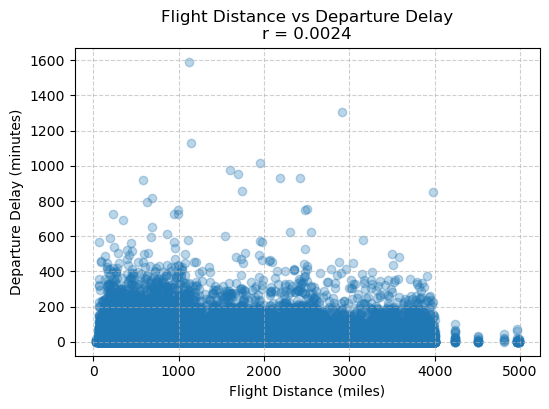

In [22]:
# 4. Tính hệ số tương quan và vẽ biểu đồ

# 4.1 Flight Distance ~ Departure Delay in Minutes
print("\nTương quan: Flight Distance ~ Departure Delay in Minutes")
x = df_merged["Flight Distance"]
y = df_merged["Departure Delay in Minutes"]
r1 = x.corr(y)
print(f"Hệ số tương quan r = {r1:.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(x, y, alpha=0.3)
plt.title(f"Flight Distance vs Departure Delay\nr = {r1:.4f}")
plt.xlabel("Flight Distance (miles)")
plt.ylabel("Departure Delay (minutes)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


**Nhận xét:**
1. Hệ số tương quan r = 0.0024 → gần bằng 0 => Điều này cho thấy không có mối liên hệ tuyến tính giữa khoảng cách bay và thời gian trễ khi khởi hành.


 => Kết luận: chuyến bay dài hay ngắn không ảnh hưởng đến việc máy bay cất cánh đúng giờ hay trễ.


Tương quan: Departure Delay ~ Arrival Delay
Hệ số tương quan r = 0.9652


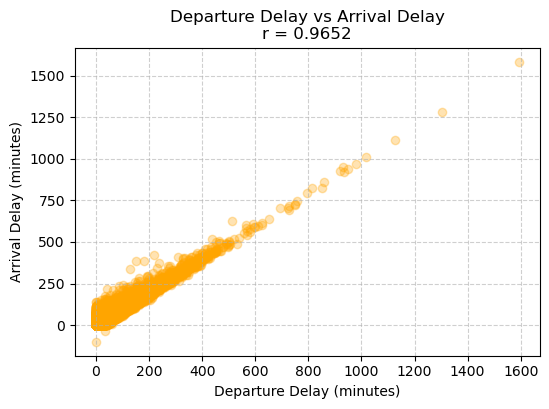

In [24]:
# 4.2 Departure Delay ~ Arrival Delay
print("\nTương quan: Departure Delay ~ Arrival Delay")
x = df_merged["Departure Delay in Minutes"]
y = df_merged["Arrival Delay in Minutes"]
r2 = x.corr(y)
print(f"Hệ số tương quan r = {r2:.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(x, y, alpha=0.3, color="orange")
plt.title(f"Departure Delay vs Arrival Delay\nr = {r2:.4f}")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

**Nhận xét:**
1. Hệ số tương quan r = 0.9652 → rất gần 1.

=> Điều này chứng tỏ có tương quan tuyến tính dương cực mạnh: nếu chuyến bay xuất phát muộn, thì gần như chắc chắn cũng sẽ đến muộn.

## 4. Làm sạch và chuẩn bị dữ liệu (Preparation)
---

1. Kiểm tra và xử lý các dữ liệu thiếu trong Dataset  (nếu có)
2. Kiểm tra và xử lý dữ liệu ngoại lai trong Dataset (nếu có)
3. Kiểm tra và xử lý dữ liệu trùng lặp trong Dataset (nếu có)
4. Theo quy định của ngành hàng không, các chuyến bay có thời gian khởi hành trễ hơn 15 phút so với lịch bay được tính là chuyến bay trễ (Delay). Dựa trên cột thời gian trễ của chuyến bay tại sân bay khởi hành (Departure Delay in Minutes), tạo thêm một cột mới đặt tên là “Delay” bằng cách rời rạc hóa dữ liệu của cột Departure Delay in Minutes về dạng dữ liệu nhị phân; nếu < 15 thành giá trị No, ngược lại >=15 thành Yes
5. Lưu tập dữ liệu đã xử lý ra file: Data_Airlines_OK.CSV

### 4.1 Phát hiện và xử lý dữ liệu thiếu (Missing Data)
---

In [ ]:
#Sinh viên viết mã xử lý vào đây!


In [26]:
print(df_merged.isnull().sum())



Code                                     0
Gender                                   2
Customer Type                            2
Age                                      2
State                                70772
Type of Travel                           2
Class                                    2
Flight Distance                          2
Departure Delay in Minutes               2
Arrival Delay in Minutes               393
Inflight wifi service                    3
Departure/Arrival time convenient        3
Ease of Online booking                   3
Food and drink                           3
Seat comfort                             3
Inflight entertainment                   3
Baggage handling                         3
Checkin service                          3
Inflight service                         3
Cleanliness                              3
satisfaction                             3
dtype: int64


In [30]:
#với số thì thay bằng median, với object thì thay bằng mode
for col in df_merged.columns:
    if df_merged[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df_merged[col]):
            df_merged[col].fillna(df_merged[col].median(), inplace=True)
        else:
            df_merged[col].fillna(df_merged[col].mode()[0], inplace=True)

In [32]:
print('Sau xử lý:')
print(df_merged.isnull().sum())

Sau xử lý:
Code                                 0
Gender                               0
Customer Type                        0
Age                                  0
State                                0
Type of Travel                       0
Class                                0
Flight Distance                      0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Food and drink                       0
Seat comfort                         0
Inflight entertainment               0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
satisfaction                         0
dtype: int64


### 4.2 Phát hiện và xử lý dữ liệu ngoại lai (Ouliers data)
---

In [34]:
#Sinh viên viết mã xử lý vào đây!
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns

#quy tắc Tukey dùng IQR
for col in numeric_cols:
    Q1 = df_merged[col].quantile(0.25)
    Q3 = df_merged[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df_merged[(df_merged[col] < lower) | (df_merged[col] > upper)]
    print(f"{col}: {len(outliers)} ngoại lai")



Age: 1 ngoại lai
Flight Distance: 2855 ngoại lai
Departure Delay in Minutes: 18097 ngoại lai
Arrival Delay in Minutes: 17494 ngoại lai
Inflight wifi service: 0 ngoại lai
Departure/Arrival time convenient: 0 ngoại lai
Ease of Online booking: 1 ngoại lai
Food and drink: 0 ngoại lai
Seat comfort: 0 ngoại lai
Inflight entertainment: 0 ngoại lai
Baggage handling: 0 ngoại lai
Checkin service: 0 ngoại lai
Inflight service: 0 ngoại lai
Cleanliness: 0 ngoại lai


In [38]:
# cắt ngưỡng về [lower, upper]
for col in numeric_cols:
    Q1 = df_merged[col].quantile(0.25)
    Q3 = df_merged[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_merged[col] = np.where(df_merged[col] < lower, lower,
                       np.where(df_merged[col] > upper, upper, df_merged[col]))

In [40]:
# kiểm tra lại ngoại lai
for col in numeric_cols:
    Q1 = df_merged[col].quantile(0.25)
    Q3 = df_merged[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_merged[(df_merged[col] < lower) | (df_merged[col] > upper)]
    print(f"{col}: {len(outliers)} ngoại lai (đã xử lý)")

Age: 0 ngoại lai (đã xử lý)
Flight Distance: 0 ngoại lai (đã xử lý)
Departure Delay in Minutes: 0 ngoại lai (đã xử lý)
Arrival Delay in Minutes: 0 ngoại lai (đã xử lý)
Inflight wifi service: 0 ngoại lai (đã xử lý)
Departure/Arrival time convenient: 0 ngoại lai (đã xử lý)
Ease of Online booking: 0 ngoại lai (đã xử lý)
Food and drink: 0 ngoại lai (đã xử lý)
Seat comfort: 0 ngoại lai (đã xử lý)
Inflight entertainment: 0 ngoại lai (đã xử lý)
Baggage handling: 0 ngoại lai (đã xử lý)
Checkin service: 0 ngoại lai (đã xử lý)
Inflight service: 0 ngoại lai (đã xử lý)
Cleanliness: 0 ngoại lai (đã xử lý)


### 4.3 Phát hiện và xử lý dữ liệu trung lặp (Duplicate data)
---

In [42]:
#Sinh viên viết mã xử lý vào đây!
duplicates = df_merged.duplicated().sum()
print(f"Số dòng trùng lặp: {duplicates}")


df_merged.drop_duplicates(inplace=True)


Số dòng trùng lặp: 4


In [44]:
duplicates = df_merged.duplicated().sum()
print(f"Kiểm tra lại số dòng trùng lặp: {duplicates}")

Kiểm tra lại số dòng trùng lặp: 0


### 4.4 Rời rạc hóa dữ liệu
---

In [46]:
#Sinh viên viết mã xử lý vào đây!
df_merged["Delay"] = df_merged["Departure Delay in Minutes"].apply(lambda x: "Yes" if x >= 15 else "No")

print(df_merged[["Departure Delay in Minutes", "Delay"]].head(10))

    Departure Delay in Minutes Delay
0                         25.0   Yes
1                          1.0    No
2                          0.0    No
3                         11.0    No
4                          0.0    No
5                         23.0   Yes
7                          0.0    No
8                          9.0    No
9                          4.0    No
10                         0.0    No


### 4.5 Lưu dữ liệu
---

In [48]:
#Sinh viên viết mã xử lý vào đây!
output_path = "Data_Airlines_OK.csv"
df_merged.to_csv(output_path, index=False, encoding="utf-8-sig")